Phase 5.3 — Stage B grid: dropout x L2 sweep at fixed `emb_dim=32` (chosen by Stage A in 05b). Stage A confirmed bigger emb is better but the train-loss slope is still steep at epoch 10, so the model is leaving capacity on the table — the regularization in the default config (dropout=0.2 / l2=1e-4) is too weak. This grid runs 5 dropout values x 4 L2 values = 20 configs to find the regularization that gives the best NDCG@10 without over-suppressing the deeper interactions.

**v2 update**: DeepFM input now includes the 32-d `item_text_emb_pca32` from Phase 3 (sentence-transformer ColBERT-light). The FM 2nd-order term grows from 4 fields to 5 (adds `item_text_proj`), the DNN input grows by 32, and the linear features layer covers it too. This should help cold-start items, evaluated separately in Phase 7.

In [1]:
import json
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import platform

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S", force=True)
log = logging.getLogger(__name__)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
FEATURES_DIR = PROJECT_ROOT / "data" / "features"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"arch: {platform.machine()}  device: {DEVICE}")

arch: arm64  device: mps


Inline IDEncoder + Dataset + eval (same as 05a/05b, with v2 `item_text` field added).

In [2]:
class IDEncoder:
    def __init__(self, ids, oov_token="<UNK>"):
        oov_markers = {"<NEW_USER>", "<NEW_BUSINESS>", "<UNK>", oov_token}
        unique_real_ids = sorted({i for i in ids if i not in oov_markers})
        self.id_to_idx = {oov_token: 0}
        for idx, _id in enumerate(unique_real_ids, start=1):
            self.id_to_idx[_id] = idx
        for marker in oov_markers:
            self.id_to_idx.setdefault(marker, 0)
        self._size = 1 + len(unique_real_ids)

    def __len__(self):
        return self._size

    def encode(self, _id):
        return self.id_to_idx.get(_id, 0)

    def encode_array(self, ids):
        return ids.map(self.id_to_idx).fillna(0).astype(np.int64).values


class TasteHunterDataset(Dataset):
    def __init__(self, df, user_encoder, item_encoder, user_features, item_features):
        self.user_idx = torch.from_numpy(user_encoder.encode_array(df["user_id"]))
        self.item_idx = torch.from_numpy(item_encoder.encode_array(df["business_id"]))
        self.label = torch.from_numpy(df["label"].astype(np.float32).values)
        n_users = len(user_encoder)
        n_items = len(item_encoder)
        self.user_num = np.zeros((n_users, 6), dtype=np.float32)
        self.user_cuisine = np.zeros((n_users, 50), dtype=np.float32)
        for _, row in user_features.iterrows():
            uidx = user_encoder.encode(row["user_id"])
            self.user_num[uidx] = [row["avg_rating_given"], row["review_count_log"], row["days_active"],
                                    row["elite_flag"], row["mean_distance_traveled"], row["price_tolerance_avg"]]
            emb = row["fav_cuisine_emb"]
            if isinstance(emb, list) and len(emb) == 50:
                self.user_cuisine[uidx] = emb
        self.item_num = np.zeros((n_items, 7), dtype=np.float32)
        self.item_cat = np.zeros((n_items, 50), dtype=np.float32)
        self.item_text = np.zeros((n_items, 32), dtype=np.float32)
        for _, row in item_features.iterrows():
            iidx = item_encoder.encode(row["business_id"])
            self.item_num[iidx] = [row["avg_rating"], row["review_count_log"], row["price_level"],
                                    row["is_open"], row["has_outdoor_seating"], row["photo_count_log"], row["city_id"]]
            cat = row["categories_multi_hot"]
            if isinstance(cat, list) and len(cat) == 50:
                self.item_cat[iidx] = cat
            text = row.get("item_text_emb_pca32")
            if isinstance(text, (list, np.ndarray)) and len(text) == 32:
                self.item_text[iidx] = np.asarray(text, dtype=np.float32)
        self.user_num_t = torch.from_numpy(self.user_num)
        self.user_cuisine_t = torch.from_numpy(self.user_cuisine)
        self.item_num_t = torch.from_numpy(self.item_num)
        self.item_cat_t = torch.from_numpy(self.item_cat)
        self.item_text_t = torch.from_numpy(self.item_text)

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        u = self.user_idx[idx]
        i = self.item_idx[idx]
        return {
            "user_idx": u, "item_idx": i, "label": self.label[idx],
            "user_num": self.user_num_t[u], "user_cuisine": self.user_cuisine_t[u],
            "item_num": self.item_num_t[i], "item_cat": self.item_cat_t[i],
            "item_text": self.item_text_t[i],
        }


def make_val_eval_pairs(val_df, user_encoder, item_encoder, item_features, n_negs=99, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    val_pos = val_df[val_df["stars"] >= 4].copy()
    biz_city = item_features.set_index("business_id")["city"].to_dict()
    val_pos["city"] = val_pos["business_id"].map(biz_city).fillna("<UNK>")
    city_biz = {}
    for bid, c in biz_city.items():
        if c == "<UNK>":
            continue
        city_biz.setdefault(c, []).append(bid)
    for c in city_biz:
        city_biz[c] = np.array(city_biz[c])
    all_user, all_item, all_label = [], [], []
    for row in val_pos.itertuples(index=False):
        if row.city not in city_biz:
            continue
        candidates = city_biz[row.city]
        sampled = rng.choice(candidates, size=n_negs * 2, replace=True)
        negs = [b for b in sampled if b != row.business_id][:n_negs]
        if len(negs) < n_negs:
            continue
        items = [row.business_id] + negs
        all_user.append([user_encoder.encode(row.user_id)] * (n_negs + 1))
        all_item.append([item_encoder.encode(b) for b in items])
        all_label.append([1.0] + [0.0] * n_negs)
    return (np.array(all_user, dtype=np.int64),
            np.array(all_item, dtype=np.int64),
            np.array(all_label, dtype=np.float32))


def compute_auc(scores, labels):
    pos_mask = labels > 0.5
    n_pos = pos_mask.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(scores)
    ranks = np.empty(len(scores))
    ranks[order] = np.arange(1, len(scores) + 1)
    return float((ranks[pos_mask].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def ndcg_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = (top_k_labels * discounts).sum(axis=1)
    ideal_labels = -np.sort(-label_matrix, axis=1)[:, :k]
    idcg = (ideal_labels * discounts).sum(axis=1)
    idcg = np.where(idcg > 0, idcg, 1.0)
    return float(np.mean(dcg / idcg))


def recall_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    n_pos_per_row = label_matrix.sum(axis=1)
    correct = top_k_labels.sum(axis=1)
    return float(np.mean(np.where(n_pos_per_row > 0, correct / n_pos_per_row, 0)))


@torch.no_grad()
def score_pairs(model, user_idx, item_idx, dataset, device, batch_size=8192):
    model.eval()
    n, c = user_idx.shape
    flat_u = user_idx.reshape(-1)
    flat_i = item_idx.reshape(-1)
    scores = np.zeros(n * c, dtype=np.float32)
    for start in range(0, len(flat_u), batch_size):
        end = min(start + batch_size, len(flat_u))
        u_b = torch.from_numpy(flat_u[start:end]).to(device)
        i_b = torch.from_numpy(flat_i[start:end]).to(device)
        u_t = torch.from_numpy(flat_u[start:end])
        i_t = torch.from_numpy(flat_i[start:end])
        kwargs = {
            "user_num": dataset.user_num_t[u_t].to(device),
            "user_cuisine": dataset.user_cuisine_t[u_t].to(device),
            "item_num": dataset.item_num_t[i_t].to(device),
            "item_cat": dataset.item_cat_t[i_t].to(device),
            "item_text": dataset.item_text_t[i_t].to(device),
        }
        s = model(u_b, i_b, **kwargs).cpu().numpy().reshape(-1)
        scores[start:end] = s
    return scores.reshape(n, c)


def evaluate_full(model, user_idx_eval, item_idx_eval, label_eval, dataset, device):
    score_matrix = score_pairs(model, user_idx_eval, item_idx_eval, dataset, device)
    return {
        "AUC": compute_auc(score_matrix.reshape(-1), label_eval.reshape(-1)),
        "NDCG@10": ndcg_at_k(score_matrix, label_eval, k=10),
        "Recall@10": recall_at_k(score_matrix, label_eval, k=10),
    }

**DeepFM v2** — same architecture as 05a/05b but the FM 2nd-order term covers 5 fields (adds `item_text_proj`), the DNN input grows by 32, and the linear features layer takes the 32-d text emb too. The added projection `item_text_proj: Linear(32, emb_dim)` lets the 32-d text emb participate in the pairwise interaction with `user_emb` etc.

In [3]:
class DeepFM(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32,
                 user_num_dim=6, user_cuisine_dim=50,
                 item_num_dim=7, item_cat_dim=50, item_text_dim=32,
                 dnn_hidden=(256, 128, 64), dropout=0.2, ablate_user_id=False):
        super().__init__()
        self.emb_dim = emb_dim
        self.ablate_user_id = ablate_user_id
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_num_proj = nn.Linear(user_num_dim, emb_dim)
        self.item_num_proj = nn.Linear(item_num_dim, emb_dim)
        self.item_text_proj = nn.Linear(item_text_dim, emb_dim)

        feat_dim_linear = user_num_dim + item_num_dim + user_cuisine_dim + item_cat_dim + item_text_dim
        self.linear_features = nn.Linear(feat_dim_linear, 1)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        # 5 fields stacked for FM 2nd-order: user_emb, item_emb, user_num_proj, item_num_proj, item_text_proj
        # DNN input: 5 emb fields + 2 multi-hot (cuisine 50, cat 50) + raw text 32
        dnn_input_dim = emb_dim * 5 + user_cuisine_dim + item_cat_dim + item_text_dim
        layers = []
        prev = dnn_input_dim
        for h in dnn_hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.dnn = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_idx, item_idx, user_num, user_cuisine, item_num, item_cat, item_text):
        u_emb = self.user_emb(user_idx)
        i_emb = self.item_emb(item_idx)
        un_emb = self.user_num_proj(user_num)
        in_emb = self.item_num_proj(item_num)
        it_emb = self.item_text_proj(item_text)

        if self.ablate_user_id:
            u_emb = torch.zeros_like(u_emb)

        feat_concat = torch.cat([user_num, item_num, user_cuisine, item_cat, item_text], dim=-1)
        order1 = self.linear_features(feat_concat).squeeze(-1)
        bu = self.user_bias(user_idx).squeeze(-1)
        bi = self.item_bias(item_idx).squeeze(-1)
        if self.ablate_user_id:
            bu = torch.zeros_like(bu)

        embs = torch.stack([u_emb, i_emb, un_emb, in_emb, it_emb], dim=1)
        sum_sq = embs.sum(dim=1) ** 2
        sq_sum = (embs ** 2).sum(dim=1)
        order2 = 0.5 * (sum_sq - sq_sum).sum(dim=-1)

        dnn_input = torch.cat([u_emb, i_emb, un_emb, in_emb, it_emb, user_cuisine, item_cat, item_text], dim=-1)
        dnn_output = self.dnn(dnn_input).squeeze(-1)

        return torch.sigmoid(order1 + order2 + dnn_output + bu + bi + self.global_bias)


def train_one(config, n_users, n_items, train_loader, ue, ie, le, dataset, device, max_epochs=10):
    torch.manual_seed(SEED)
    model = DeepFM(n_users, n_items, emb_dim=config["emb_dim"], dropout=config["dropout"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get("lr", 1e-3), weight_decay=config["l2"])
    bce = nn.BCELoss()
    history = {"epoch": [], "train_loss": [], "val_auc": [], "val_ndcg10": [], "val_recall10": []}
    for epoch in range(1, max_epochs + 1):
        model.train()
        loss_sum, n_batch = 0.0, 0
        t0 = time.time()
        for batch in train_loader:
            u = batch["user_idx"].to(device)
            i = batch["item_idx"].to(device)
            y = batch["label"].to(device)
            kwargs = {k: batch[k].to(device) for k in ("user_num", "user_cuisine", "item_num", "item_cat", "item_text")}
            pred = model(u, i, **kwargs)
            loss = bce(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            n_batch += 1
        train_loss = loss_sum / n_batch
        elapsed = time.time() - t0
        m = evaluate_full(model, ue, ie, le, dataset, device)
        print(f"  ep{epoch:02d} | {elapsed:.0f}s | loss={train_loss:.4f} | AUC={m['AUC']:.4f} NDCG@10={m['NDCG@10']:.4f}")
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_auc"].append(m["AUC"])
        history["val_ndcg10"].append(m["NDCG@10"])
        history["val_recall10"].append(m["Recall@10"])
    history["best_ndcg10"] = max(history["val_ndcg10"])
    history["best_auc"] = max(history["val_auc"])
    history["best_recall10"] = max(history["val_recall10"])
    history["config"] = config
    return history

Load data once.

In [4]:
user_features = pd.read_parquet(FEATURES_DIR / "user_features.parquet")
item_features = pd.read_parquet(FEATURES_DIR / "item_features.parquet")
val_df = pd.read_parquet(CLEANED_DIR / "val_reviews.parquet")
train_df = pd.read_parquet(FEATURES_DIR / "train_with_negatives.parquet")

assert "item_text_emb_pca32" in item_features.columns, "v2 item_text_emb_pca32 missing — re-run Phase 3"

user_encoder = IDEncoder(user_features["user_id"].tolist(), oov_token="<NEW_USER>")
item_encoder = IDEncoder(item_features["business_id"].tolist(), oov_token="<NEW_BUSINESS>")
n_users, n_items = len(user_encoder), len(item_encoder)

user_idx_eval, item_idx_eval, label_eval = make_val_eval_pairs(
    val_df, user_encoder, item_encoder, item_features, n_negs=99,
)

t0 = time.time()
train_ds = TasteHunterDataset(train_df, user_encoder, item_encoder, user_features, item_features)
print(f"train dataset: {len(train_ds)} samples ({time.time()-t0:.1f}s)")
train_loader = DataLoader(train_ds, batch_size=8192, shuffle=True, num_workers=0, pin_memory=True)

/var/folders/4j/cfzmxp0d3db8xdcx2fncnbnc0000gn/T/ipykernel_17111/2717135169.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.user_idx = torch.from_numpy(user_encoder.encode_array(df["user_id"]))


train dataset: 2075285 samples (4.6s)


Run the 5x4 grid. Per config ~6-7 min on arm64, total ~2-2.5 hours.

In [5]:
DROPOUTS = [0.1, 0.2, 0.3, 0.4, 0.5]
L2S = [1e-5, 1e-4, 5e-4, 1e-3]
EMB_DIM = 32   # locked from Stage A

grid_results = []
total = len(DROPOUTS) * len(L2S)
counter = 0
t_start = time.time()

for d in DROPOUTS:
    for l in L2S:
        counter += 1
        elapsed_total = time.time() - t_start
        print(f"\n=== [{counter}/{total}] dropout={d}, l2={l:.0e}  (elapsed: {elapsed_total/60:.1f} min) ===")
        config = {"emb_dim": EMB_DIM, "dropout": d, "l2": l, "lr": 1e-3, "epochs": 10}
        h = train_one(config, n_users, n_items, train_loader,
                      user_idx_eval, item_idx_eval, label_eval, train_ds, DEVICE)
        tag = f"emb{EMB_DIM}_drop{d}_l2{l:.0e}_v2"
        with open(MODELS_DIR / f"deepfm_{tag}_history.json", "w") as f:
            json.dump(h, f, indent=2)
        grid_results.append({
            "emb_dim": EMB_DIM, "dropout": d, "l2": l,
            "best_auc": h["best_auc"], "best_ndcg10": h["best_ndcg10"], "best_recall10": h["best_recall10"],
            "tag": tag,
        })

with open(MODELS_DIR / "deepfm_sweep_dropout_l2.json", "w") as f:
    json.dump(grid_results, f, indent=2)

print(f"\n=== Stage B complete in {(time.time()-t_start)/60:.1f} min ===")
print(f"{'dropout':<10}{'l2':<12}{'AUC':<10}{'NDCG@10':<10}{'Recall@10':<10}")
for r in sorted(grid_results, key=lambda x: -x["best_ndcg10"])[:10]:
    print(f"{r['dropout']:<10}{r['l2']:<12.0e}{r['best_auc']:<10.4f}{r['best_ndcg10']:<10.4f}{r['best_recall10']:<10.4f}")

best = max(grid_results, key=lambda x: x["best_ndcg10"])
print(f"\n=> best: dropout={best['dropout']}, l2={best['l2']:.0e} -> NDCG@10={best['best_ndcg10']:.4f}")


=== [1/20] dropout=0.1, l2=1e-05  (elapsed: 0.0 min) ===


/Users/yanghaobo/miniforge3/envs/yelp-arm64/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  ep01 | 30s | loss=0.6670 | AUC=0.7863 NDCG@10=0.2606


  ep02 | 27s | loss=0.3141 | AUC=0.8009 NDCG@10=0.2779


  ep03 | 26s | loss=0.2894 | AUC=0.8175 NDCG@10=0.2950


...

  ep06 | 27s | loss=0.3187 | AUC=0.8318 NDCG@10=0.2787


  ep07 | 27s | loss=0.3156 | AUC=0.8405 NDCG@10=0.2863


  ep08 | 27s | loss=0.3138 | AUC=0.8434 NDCG@10=0.2898


  ep09 | 27s | loss=0.3121 | AUC=0.8443 NDCG@10=0.2921


  ep10 | 27s | loss=0.3113 | AUC=0.8450 NDCG@10=0.2937

=== Stage B complete in 99.9 min ===
dropout   l2          AUC       NDCG@10   Recall@10 
0.1       1e-04       0.8502    0.3255    0.5510    
0.2       1e-04       0.8436    0.3219    0.5463    
0.1       5e-04       0.8534    0.3213    0.5413    
0.3       1e-04       0.8438    0.3203    0.5431    
0.2       5e-04       0.8513    0.3184    0.5373    
0.4       1e-04       0.8405    0.3172    0.5392    
0.5       1e-04       0.8377    0.3100    0.5281    
0.3       5e-04       0.8487    0.3082    0.5221    
0.4       5e-04       0.8499    0.3078    0.5217    
0.2       1e-03       0.8511    0.3033    0.5162    

=> best: dropout=0.1, l2=1e-04 -> NDCG@10=0.3255


Plot the grid as a heatmap of best NDCG@10 per (dropout, L2) cell.

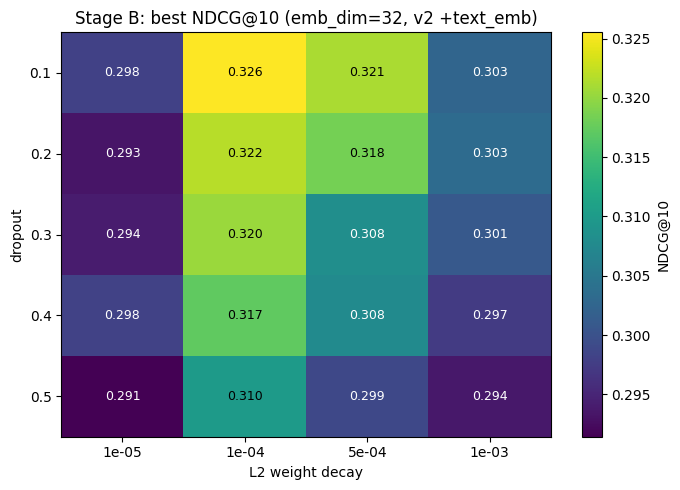

In [6]:
import numpy as np
heat = np.zeros((len(DROPOUTS), len(L2S)))
for i, d in enumerate(DROPOUTS):
    for j, l in enumerate(L2S):
        match = [r for r in grid_results if r["dropout"] == d and abs(r["l2"] - l) < 1e-12]
        heat[i, j] = match[0]["best_ndcg10"] if match else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(L2S)))
ax.set_xticklabels([f"{l:.0e}" for l in L2S])
ax.set_yticks(range(len(DROPOUTS)))
ax.set_yticklabels(DROPOUTS)
ax.set_xlabel("L2 weight decay")
ax.set_ylabel("dropout")
ax.set_title(f"Stage B: best NDCG@10 (emb_dim={EMB_DIM}, v2 +text_emb)")
for i in range(len(DROPOUTS)):
    for j in range(len(L2S)):
        ax.text(j, i, f"{heat[i, j]:.3f}", ha="center", va="center",
                color="white" if heat[i, j] < heat.max() * 0.95 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="NDCG@10")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_deepfm_dropout_l2_grid.png", bbox_inches="tight")
plt.show()

Phase 5.4 takes the (dropout, L2) winner from this grid + emb_dim=32 + v2 text_emb and retrains on train+val merged for the final model. Phase 5.5 ablates user_id embedding to verify hypothesis H6.